# 2. Entrainement des modeles CNN
## Projet B3 Deep Learning -- Detection de pneumonie

**Contexte medical** : ce projet s'inscrit dans le cadre d'un outil d'aide a la decision medicale. Le modele vise a assister les praticiens dans la detection de pneumonies sur radiographies thoraciques, et non a remplacer le medecin. Toute utilisation clinique reelle necessite une validation rigoureuse, des certifications reglementaires, et la supervision d'un professionnel de sante.

On entraine ici :
1. **CNN baseline** (from scratch, 3 blocs convolutifs)
2. **ResNet18** (transfer learning, fine-tuning layer4)
3. **DenseNet121** (transfer learning, fine-tuning denseblock4)
4. **EfficientNet-B0** (transfer learning, fine-tuning derniers blocs)

---

In [9]:
import os, sys, json, time
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.dataset import (
    create_dataloaders, IMAGENET_MEAN, IMAGENET_STD,
    get_no_augment_transform, get_train_transform, get_strong_augment_transform,
)
from src.model import create_model
from src.train import train_model

# Reproductibilite
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device : {device}")

# Hyperparametres
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
PATIENCE = 7
DATA_DIR = Path("../data/chest_xray")
CHECKPOINT_DIR = Path("../outputs/checkpoints")
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

Device : mps


## 2.1 Chargement des donnees

In [2]:
train_loader, val_loader, test_loader, class_names, class_weights = create_dataloaders(
    data_dir=DATA_DIR,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=0.15,
    seed=SEED,
)

Donnees chargees :
   Train :      4433 images
   Validation : 783 images (split stratifie)
   Test :       624 images
   Classes :    ['NORMAL', 'PNEUMONIA']
   NORMAL: 1140 (weight: 1.944)
   PNEUMONIA: 3293 (weight: 0.673)


## 2.2 Controle visuel d'un batch

**Choix du pretraitement : Resize direct (224x224) sans CenterCrop**

On utilise un Resize direct plutot que Resize + CenterCrop. Les radiographies thoraciques sont naturellement centrees sur le thorax, et un CenterCrop risquerait de couper des zones pertinentes sur les bords des poumons (apex, bases, angles costophreniques). Le Resize preserve l'integralite de l'information spatiale.

/Users/mke-kapoor/Documents/Projects/medical-cnn-project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


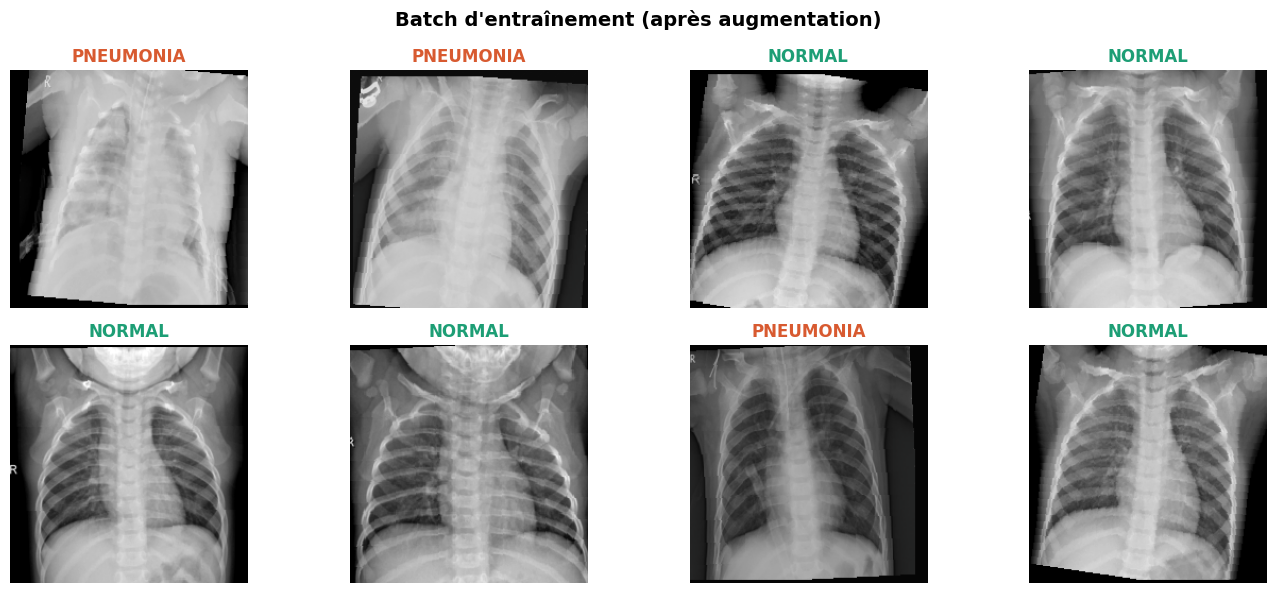

In [10]:
images, labels = next(iter(train_loader))
mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std = torch.tensor(IMAGENET_STD).view(3,1,1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    if i >= len(images): break
    img = (images[i] * std + mean).clamp(0,1).permute(1,2,0).numpy()
    ax.imshow(img)
    cls = class_names[labels[i].item()]
    ax.set_title(cls, fontweight="bold", color="#1D9E75" if cls=="NORMAL" else "#D85A30")
    ax.axis("off")
plt.suptitle("Batch d'entraînement (après augmentation)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.3 Entrainement du CNN baseline

In [11]:
ckpt_path = CHECKPOINT_DIR / "best_cnn_baseline.pt"
if ckpt_path.exists():
    print("Checkpoint trouve, entrainement skippe.")
    ckpt = torch.load(ckpt_path, map_location=device)
    model_baseline = create_model("cnn_baseline", dropout_rate=0.5, device=device)
    model_baseline.load_state_dict(ckpt["model_state_dict"])
    history_baseline = ckpt.get("history", {})
    print(f"Charge depuis epoque {ckpt['epoch']} (val_loss: {ckpt['val_loss']:.4f})")
else:
    model_baseline = create_model("cnn_baseline", dropout_rate=0.5, device=device)
    history_baseline = train_model(
        model=model_baseline,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        class_weights=class_weights,
        num_epochs=NUM_EPOCHS,
        learning_rate=1e-3,
        patience=PATIENCE,
        checkpoint_dir=CHECKPOINT_DIR,
        model_name="cnn_baseline",
    )

Checkpoint trouve, entrainement skippe.
Modele : cnn_baseline
   Parametres totaux :       12,939,009
   Parametres entrainables : 12,939,009
Charge depuis epoque 11 (val_loss: 0.0345)


## 2.4 Entrainement de ResNet18 (transfer learning)

On utilise un ResNet18 pre-entraine sur ImageNet. On gele le backbone et on fine-tune uniquement `layer4` + le classifieur.

In [12]:
ckpt_path = CHECKPOINT_DIR / "best_resnet18.pt"
if ckpt_path.exists():
    print("Checkpoint trouve, entrainement skippe.")
    ckpt = torch.load(ckpt_path, map_location=device)
    model_resnet = create_model("resnet18", dropout_rate=0.5, fine_tune=True, device=device)
    model_resnet.load_state_dict(ckpt["model_state_dict"])
    history_resnet = ckpt.get("history", {})
    print(f"Charge depuis epoque {ckpt['epoch']} (val_loss: {ckpt['val_loss']:.4f})")
else:
    model_resnet = create_model("resnet18", dropout_rate=0.5, fine_tune=True, device=device)
    history_resnet = train_model(
        model=model_resnet,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        class_weights=class_weights,
        num_epochs=NUM_EPOCHS,
        learning_rate=1e-4,
        patience=PATIENCE,
        checkpoint_dir=CHECKPOINT_DIR,
        model_name="resnet18",
    )

Checkpoint trouve, entrainement skippe.
Modele : resnet18
   Parametres totaux :       11,308,097
   Parametres entrainables : 8,525,313
Charge depuis epoque 2 (val_loss: 0.0277)


## 2.5 Entrainement de DenseNet121 (transfer learning)

DenseNet121 est un choix classique en imagerie medicale (c'est l'architecture de CheXNet, un modele de reference pour la detection de pathologies thoraciques).

In [13]:
ckpt_path = CHECKPOINT_DIR / "best_densenet121.pt"
if ckpt_path.exists():
    print("Checkpoint trouve, entrainement skippe.")
    ckpt = torch.load(ckpt_path, map_location=device)
    model_densenet = create_model("densenet121", dropout_rate=0.5, fine_tune=True, device=device)
    model_densenet.load_state_dict(ckpt["model_state_dict"])
    history_densenet = ckpt.get("history", {})
    print(f"Charge depuis epoque {ckpt['epoch']} (val_loss: {ckpt['val_loss']:.4f})")
else:
    model_densenet = create_model("densenet121", dropout_rate=0.5, fine_tune=True, device=device)
    history_densenet = train_model(
        model=model_densenet,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        class_weights=class_weights,
        num_epochs=NUM_EPOCHS,
        learning_rate=1e-4,
        patience=PATIENCE,
        checkpoint_dir=CHECKPOINT_DIR,
        model_name="densenet121",
    )

Checkpoint trouve, entrainement skippe.
Modele : densenet121
   Parametres totaux :       7,216,513
   Parametres entrainables : 2,420,737
Charge depuis epoque 10 (val_loss: 0.0295)


## 2.6 Entrainement de EfficientNet-B0 (transfer learning)

EfficientNet-B0 utilise le compound scaling pour un excellent ratio performance/parametres. On fine-tune les deux derniers blocs de features.

In [14]:
ckpt_path = CHECKPOINT_DIR / "best_efficientnet.pt"
if ckpt_path.exists():
    print("Checkpoint trouve, entrainement skippe.")
    ckpt = torch.load(ckpt_path, map_location=device)
    model_efficientnet = create_model("efficientnet", dropout_rate=0.5, fine_tune=True, device=device)
    model_efficientnet.load_state_dict(ckpt["model_state_dict"])
    history_efficientnet = ckpt.get("history", {})
    print(f"Charge depuis epoque {ckpt['epoch']} (val_loss: {ckpt['val_loss']:.4f})")
else:
    model_efficientnet = create_model("efficientnet", dropout_rate=0.5, fine_tune=True, device=device)
    history_efficientnet = train_model(
        model=model_efficientnet,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        class_weights=class_weights,
        num_epochs=NUM_EPOCHS,
        learning_rate=1e-4,
        patience=PATIENCE,
        checkpoint_dir=CHECKPOINT_DIR,
        model_name="efficientnet",
    )

Checkpoint trouve, entrainement skippe.
Modele : efficientnet
   Parametres totaux :       4,335,741
   Parametres entrainables : 1,457,585
Charge depuis epoque 19 (val_loss: 0.0247)


## 2.7 Courbes d'entrainement comparees

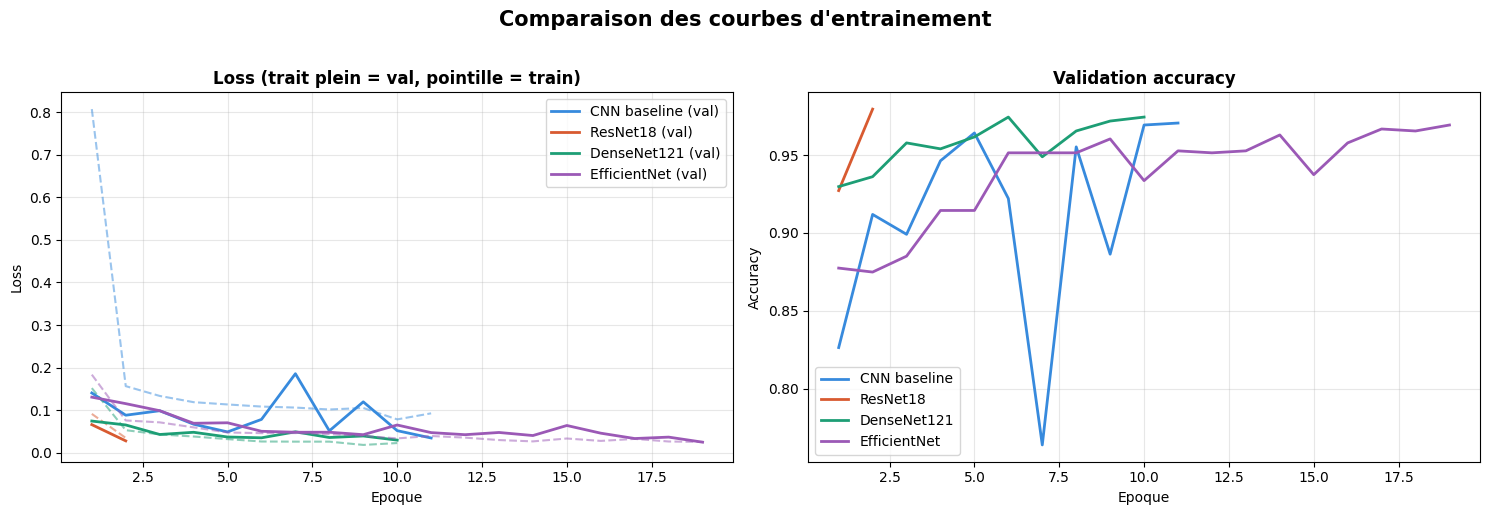

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
models_hist = {
    "CNN baseline": history_baseline,
    "ResNet18": history_resnet,
    "DenseNet121": history_densenet,
    "EfficientNet": history_efficientnet,
}
colors = ["#378ADD", "#D85A30", "#1D9E75", "#9B59B6"]

for idx, (name, h) in enumerate(models_hist.items()):
    if not h or "val_loss" not in h or len(h["val_loss"]) == 0:
        continue
    epochs = range(1, len(h["val_loss"])+1)
    axes[0].plot(epochs, h["train_loss"], color=colors[idx], linewidth=1.5, linestyle="--", alpha=0.5)
    axes[0].plot(epochs, h["val_loss"], color=colors[idx], linewidth=2, label=f"{name} (val)")

axes[0].set_xlabel("Epoque"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss (trait plein = val, pointille = train)", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for idx, (name, h) in enumerate(models_hist.items()):
    if not h or "val_acc" not in h or len(h["val_acc"]) == 0:
        continue
    epochs = range(1, len(h["val_acc"])+1)
    axes[1].plot(epochs, h["val_acc"], color=colors[idx], linewidth=2, label=f"{name}")

axes[1].set_xlabel("Epoque"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation accuracy", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparaison des courbes d'entrainement", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.8 K-fold cross-validation (optionnel)

**Attention : cette section est longue a executer** (~5x le temps d'un entrainement normal).
On lance un 5-fold stratifie sur le CNN baseline pour obtenir une estimation plus robuste des performances.

In [16]:
#Decommenter pour lancer le K-fold (long)
from src.train import train_model_kfold
from torchvision import datasets
from src.dataset import get_eval_transform

full_dataset = datasets.ImageFolder(
     root=DATA_DIR / "train",
     transform=get_eval_transform(IMG_SIZE),
)

kfold_results = train_model_kfold(
     model_name="cnn_baseline",
     full_dataset=full_dataset,
     device=device,
     class_weights=class_weights,
     k=5,
     num_epochs=NUM_EPOCHS,
     learning_rate=1e-3,
     patience=PATIENCE,
     batch_size=BATCH_SIZE,
)

print("\nResultats K-Fold :")
for metric in ["accuracy", "f1", "recall", "auc_roc"]:
     mean = kfold_results[f"{metric}_mean"]
     std = kfold_results[f"{metric}_std"]
     print(f"   {metric}: {mean:.4f} +/- {std:.4f}")

print("Section K-fold commentee (decommenter pour executer)")


Fold 1/5
Modele : cnn_baseline
   Parametres totaux :       12,939,009
   Parametres entrainables : 12,939,009
Debut de l'entrainement de 'cnn_baseline_fold1' (30 epoques max, patience=7, min_delta=0.001)
   pos_weight=0.346, lr=0.001, wd=0.0001


/Users/mke-kapoor/Documents/Projects/medical-cnn-project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Train:   0%|          | 0/131 [00:02<?, ?it/s]

  Val  :   0%|          | 0/33 [00:02<?, ?it/s]

Epoch [ 1/30] | Train Loss: 0.6670 Acc: 0.8444 | Val Loss: 0.0888 Acc: 0.9224 AUC: 0.9876 | LR: 0.001000
   Meilleur modele sauvegarde (val_loss: 0.0888)


...

  Train:   0%|          | 0/131 [00:02<?, ?it/s]

  Val  :   0%|          | 0/33 [00:02<?, ?it/s]

Epoch [13/30] | Train Loss: 0.0300 Acc: 0.9820 | Val Loss: 0.0451 Acc: 0.9751 AUC: 0.9969 | LR: 0.000500

Early stopping a l'epoque 13
Termine en 912s. Meilleur : epoque 6 (val_loss: 0.0405)


/Users/mke-kapoor/Documents/Projects/medical-cnn-project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Fold 5 -- Acc: 0.9751, F1: 0.9832, Recall: 0.9806, AUC-ROC: 0.9970

Resultats K-Fold (5 folds)
   accuracy: 0.9674 +/- 0.0116
   f1: 0.9778 +/- 0.0082
   recall: 0.9680 +/- 0.0191
   auc_roc: 0.9944 +/- 0.0033

Resultats K-Fold :
   accuracy: 0.9674 +/- 0.0116
   f1: 0.9778 +/- 0.0082
   recall: 0.9680 +/- 0.0191
   auc_roc: 0.9944 +/- 0.0033
Section K-fold commentee (decommenter pour executer)


## 2.9 Ablation study : impact de l'augmentation (optionnel)

On compare 3 configs d'augmentation sur le CNN baseline :
- **Sans augmentation** : uniquement Resize + Normalize
- **Augmentation legere** (defaut) : rotation 10, translate 0.05, zoom 0.95-1.05, jitter 0.1
- **Augmentation forte** : rotation 15, translate 0.1, zoom 0.9-1.1, jitter 0.2

In [17]:
# Decommenter pour lancer l'ablation study (long)
ablation_configs = {
     "no_augment": get_no_augment_transform(IMG_SIZE),
     "light_augment": get_train_transform(IMG_SIZE),
     "strong_augment": get_strong_augment_transform(IMG_SIZE),
}
ablation_results = {}

for config_name, transform in ablation_configs.items():
     ckpt_path = CHECKPOINT_DIR / f"best_cnn_baseline_{config_name}.pt"
     if ckpt_path.exists():
         print(f"Checkpoint trouve pour {config_name}, entrainement skippe.")
         ckpt = torch.load(ckpt_path, map_location=device)
         ablation_results[config_name] = {
             "val_loss": ckpt["val_loss"],
             "val_acc": ckpt["val_acc"],
             "epochs": ckpt["epoch"],
         }
         continue

     print(f"\n--- Entrainement avec {config_name} ---")
     tl, vl, _, _, cw = create_dataloaders(
         DATA_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE, train_transform=transform,
     )
     m = create_model("cnn_baseline", dropout_rate=0.5, device=device)
     h = train_model(
         model=m, train_loader=tl, val_loader=vl, device=device,
         class_weights=cw, num_epochs=NUM_EPOCHS, learning_rate=1e-3,
         patience=PATIENCE, checkpoint_dir=CHECKPOINT_DIR,
         model_name=f"cnn_baseline_{config_name}",
     )
     best_idx = np.argmin(h["val_loss"])
     ablation_results[config_name] = {
         "val_loss": h["val_loss"][best_idx],
         "val_acc": h["val_acc"][best_idx],
         "epochs": best_idx + 1,
     }

print("\n=== Resultats Ablation Study ===")
print(f"{'Config':<20} {'Val Loss':>10} {'Val Acc':>10} {'Epoques':>10}")
print("-" * 50)
for name, r in ablation_results.items():
     print(f"{name:<20} {r['val_loss']:>10.4f} {r['val_acc']:>10.4f} {r['epochs']:>10}")

print("Section ablation commentee (decommenter pour executer)")


--- Entrainement avec no_augment ---
Donnees chargees :
   Train :      4433 images
   Validation : 783 images (split stratifie)
   Test :       624 images
   Classes :    ['NORMAL', 'PNEUMONIA']
   NORMAL: 1140 (weight: 1.944)
   PNEUMONIA: 3293 (weight: 0.673)
Modele : cnn_baseline
   Parametres totaux :       12,939,009
   Parametres entrainables : 12,939,009
Debut de l'entrainement de 'cnn_baseline_no_augment' (30 epoques max, patience=7, min_delta=0.001)
   pos_weight=0.346, lr=0.001, wd=0.0001


/Users/mke-kapoor/Documents/Projects/medical-cnn-project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Train:   0%|          | 0/139 [00:02<?, ?it/s]

  Val  :   0%|          | 0/25 [00:04<?, ?it/s]

Epoch [ 1/30] | Train Loss: 0.8589 Acc: 0.8746 | Val Loss: 0.0590 Acc: 0.9515 AUC: 0.9935 | LR: 0.001000
   Meilleur modele sauvegarde (val_loss: 0.0590)


...

Epoch [13/30] | Train Loss: 0.1278 Acc: 0.9177 | Val Loss: 0.0759 Acc: 0.9336 AUC: 0.9934 | LR: 0.001000


/Users/mke-kapoor/Documents/Projects/medical-cnn-project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Train:   0%|          | 0/139 [00:02<?, ?it/s]

  Val  :   0%|          | 0/25 [00:05<?, ?it/s]

Epoch [14/30] | Train Loss: 0.1136 Acc: 0.9156 | Val Loss: 0.2416 Acc: 0.8225 AUC: 0.9951 | LR: 0.001000

Early stopping a l'epoque 14
Termine en 956s. Meilleur : epoque 7 (val_loss: 0.0692)

=== Resultats Ablation Study ===
Config                 Val Loss    Val Acc    Epoques
--------------------------------------------------
no_augment               0.0354     0.9693          5
light_augment            0.0561     0.9591          9
strong_augment           0.0692     0.9400         10
Section ablation commentee (decommenter pour executer)


## 2.10 Export du resume d'entrainement

In [18]:
training_summary = {}
for model_name, history_var in [
    ("cnn_baseline", history_baseline),
    ("resnet18", history_resnet),
    ("densenet121", history_densenet),
    ("efficientnet", history_efficientnet),
]:
    h = history_var
    if not h or "val_loss" not in h or len(h["val_loss"]) == 0:
        training_summary[model_name] = {"status": "non entraine"}
        continue
    best_idx = int(np.argmin(h["val_loss"]))
    entry = {
        "epochs_trained": len(h["val_loss"]),
        "best_val_loss": round(float(h["val_loss"][best_idx]), 4),
        "best_val_acc": round(float(h["val_acc"][best_idx]), 4),
    }
    if "val_auc" in h and len(h["val_auc"]) > best_idx:
        entry["best_val_auc"] = round(float(h["val_auc"][best_idx]), 4)
    if "training_time" in h:
        entry["training_time_s"] = round(float(h["training_time"]), 1)
    training_summary[model_name] = entry

with open("../outputs/training_summary.json", "w", encoding="utf-8") as f:
    json.dump(training_summary, f, indent=4, ensure_ascii=False)
print("Resume d'entrainement exporte vers outputs/training_summary.json")
for name, info in training_summary.items():
    print(f"   {name}: {info}")

Resume d'entrainement exporte vers outputs/training_summary.json
   cnn_baseline: {'epochs_trained': 11, 'best_val_loss': 0.0345, 'best_val_acc': 0.9706, 'best_val_auc': 0.998}
   resnet18: {'epochs_trained': 2, 'best_val_loss': 0.0277, 'best_val_acc': 0.9796, 'best_val_auc': 0.9983}
   densenet121: {'epochs_trained': 10, 'best_val_loss': 0.0295, 'best_val_acc': 0.9745, 'best_val_auc': 0.9985}
   efficientnet: {'epochs_trained': 19, 'best_val_loss': 0.0247, 'best_val_acc': 0.9693, 'best_val_auc': 0.999}


-> **Suite** : `03_evaluation_gradcam.ipynb`